# Marketplace Safety - Prioritering av misstänkta annonser och meddelanden

**Bakgrund**  
Detta projekt är utfört på uppdrag av analysteamet på ett företag som driver en marknadsplats-app, liknande Blocket. Plattformen används dagligen av ett stort antal användare där de allra flesta är seriösa. Varje vecka förekommer dock en mindre andel problematiska aktiviteter: bluffannonser, spam, misstänkta konton som agerar snabbt samt försök att flytta konversationer utanför plattformen.

**Problem**  
Företagets Trust & Safety-team granskar och hanterar misstänkt innehåll manuellt. Problemet är att volymen är för stor för att teamet ska hinna granska allt i tid. Ledningen efterfrågar därför ett beslutsstöd som hjälper teamet att prioritera vad som ska granskas först.

**Mål**  
Målet är att leverera en lösning som:
- presterar rimligt bra på ny, osedd data
- går att köra regelbundet i produktion
- kan förklaras för icke-tekniska stakeholders

Fokus ligger på prioritering och beslutstöd.

**Stakeholder**   
Att fylla i på slutet av projektet (kravkortet är en hemlis  🤫)

Kolumnnamn | Förklaring |
|---|---|
| `id` | Unikt identifieringsnummer för varje post |
| `day` | Dagen då händelsen inträffade |
| `event_type` | Typ av händelse (t.ex. visning, meddelande, anmälan) |
| `category` | Produktkategori för annonsen |
| `region` | Geografiskt område där annonsen publicerades |
| `device` | Enhetstyp som användes (t.ex. mobil, dator) |
| `account_age_days` | Antal dagar sedan kontot skapades |
| `num_prev_listings` | Antal tidigare annonser från samma användare |
| `prev_reports_30d` | Antal gånger användaren anmälts de senaste 30 dagarna |
| `verification_level` | Verifieringsnivå för kontot |
| `price` | Annonsens pris |
| `num_images` | Antal bilder i annonsen |
| `message_length` | Längden på meddelandet i annonsen |
| `contains_off_platform` | Om användaren försökt flytta konversationen utanför plattformen |
| `urgency_words` | Om annonsen innehåller ord som skapar artificiell brådska |
| `payment_attempt` | Om ett betalningsförsök har skett |
| `time_to_first_response_min` | Tid i minuter till första svar |
| `is_suspicious` | Målvariabel — om annonsen är misstänkt (1) eller inte (0) |

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from joblib import dump, load

from sklearn.decomposition import PCA

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,4)

# 1) Data & EDA (Isabel)

- Visa datasetstorlek, datatyper och target-fördelning.
- Kontrollera saknade värden och beskriv hur ni hanterar dem.
- Minst 2 figurer/tabeller + kort tolkning.

In [ ]:
df = pd.read_csv("../data/historical_data.csv")
df.head()

In [ ]:
print("Datasets storlek:", df.shape)
print("---------------------------")

In [ ]:
print("Datatyper")
print("---------------------------")
df.info()

### Summering av dataset

- Datasetet innehåller 12,000 observationer och 18 variabler
- Text variabler är av typ *string* och numeriska variabler är av typerna *int64* och *float64*
- Det finns fyra kategoriska värden: *event_type*, *category*, *region*, *device*
- Target är *is_suspicious*: 0 = ej misstänkt, 1 = misstänkt

## Missing values

In [ ]:
print("-------------------------------")
print("Saknade värden per kolumn (antal):")
print("-------------------------------")
print(df.isna().sum())
print("-------------------------------")
print("Saknade värden per kolumn (%):")
print("-------------------------------")
df.isnull().sum() / len(df) * 100

### Hantering av saknade värden

Andelen saknade värden är relativt låg:
- *region*: 340 (2.83 %)
- *price*: 818 (6.81 %)
- *time_to_first_response_min*: 590 (4.91%)

Eftersom klassen är obalanserad är det mindre lämpligt att droppa rader, då procent av saknade värden inte är tillräckligt låg, i ett redan obalancerat problem kan minoiritetsklassen påverkas oproportioneligt. I detta fall är det istället bättre att imputera värdena.

Saknade värden kommer därför att imputeras i pipeline med hjälp av `SimpleImputer` för att minska data-läckage genom att imputering beräknas bara på träningsdatan och sedan att samma transformation appliceras på testdata. Det gör processen reproducerbar och säker i cross-validation. 

**Numeriska variabler:**
- Saknade värden kommer att ersättas med medianen (som är tålig mot outliers) för respektive numerisk kolumn. 
- `add_indicator=True` kommer att användas för att lägga till en extra binär kolumn för varje variabel som haft saknade värden: *0 = värdet fanns, 1 = värdet saknades*. För att modellen ska kunna lära sig om ett saknat värde tenderar att tillhöra en viss klass. 
- Efter imputering standardiseras variablerna med `StandardScaler`.

**Kategoriska variabler:**
- Sakande kategoriska värden kommer att ersättas med "unknown". 
- Därefter kommer `OneHotEncoder`att användas för att göra "unknown" till sin egen kategori, för att undvika felaktig information genom att fylla med en befintlig kategori. 
- `handle_unknow="ignore"` hjälper till med att hantera att nya kategorier i testdata inte orsakar fel.

## Definera X och y

In [ ]:
X_full = df.drop(["is_suspicious"], axis=1)
y_full = df["is_suspicious"]

print("X:", X_full.shape, "y:", y_full.shape)

## Klassfördelning av target (misstänkt aktivitet)

In [ ]:
class_dist = y_full.value_counts(normalize=True) * 100

ax = sns.barplot(
    x=class_dist.index,
    y=class_dist.values
)

plt.ylabel("Procent")
plt.xlabel("Misstänkt aktivitet (0 = Nej, 1 = Ja)")
plt.title("Klassfördelning av target (%)")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

### Summering av klassfördelning
Klassfördelningen visar en tydlig obalans i datan: endast 10 % av de historiska observationerna är klassade som misstänkt aktivitet. Detta är dock förväntat, eftersom andelen misstänkt aktivitet normalt sett är låg.

## Korrelationer med target (misstänkt aktivitet)

Korrelationer visar hur starkt numeriska features separerar misstänkt aktivitet från icke-misstänkt. Kategoriska variabler utesluts eftersom korrelation mäter det linjära sambandet mellan två numeriska variabler.

In [ ]:
corr_with_target = X_full.copy()
corr_with_target["is_suspicious"] = y_full

corr_with_target = (
    corr_with_target
    .drop(["event_type", "category", "region", "device"], axis=1)
    .corr()["is_suspicious"]
    .sort_values(ascending=False)
)

print(corr_with_target)

### Summering korrelerande features

De två features som visar högst positiv korrelation med misstänkt aktivitet är *contains_off_platform* (0,14) och *prev_reports_30d* (0,13). Även om dessa samband är relativt svaga kan de ändå vara värdefulla i obalanserade klassificeringsproblem, eftersom effekten sannolikt är icke-linjär. Det finns troligen en tröskeleffekt, och dessa features kan ha större betydelse i kombination med andra variabler.

## Andel misstänka aktiviteter per kategori

Andelen misstänkt aktivitet analyseras för respektive kategorisk variabel för att undersöka om någon kategori sticker ut med en högre förekomst av misstänkt aktivitet.

In [ ]:
categorical_cols = [
    "event_type",
    "category",
    "region",
    "device"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  
axes = axes.flatten() 

temp_df = pd.concat([X_full, y_full.rename("is_suspicious")], axis=1)

for i, col in enumerate(categorical_cols):
    susp_count = (
        temp_df
        .groupby(col)["is_suspicious"]
        .mean()
        .sort_values(ascending=False) * 100
    )
    
    ax = sns.barplot(
        x=susp_count.index,
        y=susp_count.values,
        ax=axes[i]
    )
    
    ax.set_ylabel("Procent")
    ax.set_title(f"Misstänkt aktivitet per {col}")
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Summering av misstänkt aktivitet per kategori
Analysen av historisk data visar inga tydliga skillnader mellan kategorier när det gäller andelen misstänkt aktivitet. Fördelningen av misstänkta händelser inom de olika kategorierna speglar i stort den övergripande klassfördelningen och ligger konsekvent runt 10 %.

# 2) Pipeline & preprocessing (Irene)

- Skapa en train/test-split från historical_data.csv.
- Bygg en pipeline där preprocessing sker på ett sätt som undviker att testdata påverkar träningen (undvik leakage).
- För klassificering: använd gärna stratified split så klasserna fördelas rimligt.

In [ ]:
df.describe().T

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("-------------------------------")
print(f"Classification train: \n{y_train.value_counts(normalize=True)}")
print("-------------------------------")
print(f"Classification test: \n{y_test.value_counts(normalize=True)}")
print("-------------------------------")

### Summering av train/test split

Vi delar upp datan i tränings- och testset med en 80/20-fördelning. **stratify=y_full** garanterar att andelen misstänkta och icke-misstänkta fall är proportionerligt lika i både tränings- och testset.

In [ ]:
def engineer_features(X):
    X = X.copy()
    X["report_rate"] = X["prev_reports_30d"] / (X["num_prev_listings"] + 1)
    X["risk_score"] = X["contains_off_platform"] + X["urgency_words"] + X["payment_attemp"]
    return X

feature_engineer = FunctionTransformer(engineer_features)

### Summering av feature engineering

Vi skapar två nya features baserade på befintliga kolumner:
- **report_rate** normaliserar antalet anmälningar mot användarens aktivitetsnivå
- **risk_score** summerar tre binära varningssignaler till ett enda riskindex

Feature engineering handlar om att skapa nya variabler från den data vi redan har, med målet att göra mönstren tydligare för modellen.  

Dessa transformationer är inlindade i en FunctionTransformer så att de körs inuti pipelinen och aldrig appliceras före train/test-splitten.

In [ ]:
numeric_features = ["account_age_days", "num_prev_listings", "prev_reports_30d",
    "price", "num_images", "message_length", "verification_level",
    "time_to_first_response_min", "payment_attempt",
    "contains_off_platform", "urgency_words",
    # engineered features:
    "report_rate", "risk_score"]

categorical_features = ["event_type", "category", "region", "device"]

### Summering av feature selection

De numeriska och kategoriska variablerna separerades eftersom de kräver olika typer av förbehandling:  
- Numeriska variabler behöver skalas med StandardScaler för att en model son Logistic Regression inte ska påverkas av att olika kolumner har olika storleksordning.  
- Kategoriska variabler behöver istället omvandlas till binära kolumner med OneHotEncoder.

Kolumnerna **id** och **day** exkluderades eftersom det första är ett unikt identifieringsnummer utan prediktivt värde, medans den andra är ett gränsfallsbeslut som kan leda till att modellen lär sig slumpen istället förverkliga beteendemönster.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

### Summering av transformers

Vi definierar två separata transformers:
- Den numeriska transformern hanterar saknade värden med medianvärdet och använder add_indicator=True för att skapa en binär kolumn som markerar var värden saknades. Detta ger modellen möjlighet att lära sig om det finns ett samband mellan saknade värden och misstänkt aktivitet. 
- Därefter standardiseras värdena med StandardScaler. Den kategoriska transformern fyller saknade värden med konstanten "Unknown" så att missingness bevaras som en egen kategori, följt av OneHotEncoder som omvandlar textvärden till binära kolumner som modellen kan tolka.

Anledningen är att ett saknat värde i dessa kolumner potentiellt är informativt i sig: en säljare som döljer priset eller aldrig svarar kan vara ett tecken på misstänkt aktivitet.

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

Vi kombinerar de två transformers i en ColumnTransformer som applicerar rätt transformer på rätt kolumner.

**remainder="drop"** säkerställer att kolumner som inte finns i någon av listorna ignoreras.

In [ ]:
full_pipeline = Pipeline(steps=[
    ("features", feature_engineer),
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

full_pipeline

### Summering av pipeline

Vi sätter ihop alla steg i en sammanhängande Pipeline:   
- feature engineering  
- preprocessing  
- modell  

Fördelen med en pipeline är att alla transformationer appliceras automatiskt och konsekvent på både tränings- och testdata, vilket eliminerar risken för data leakage.  

För att byta model kan vi bara byta ut LogisticRegression mot en annan och allt annat fungerar automatiskt.

# 3) Modelljämförelse (Nora)

- Skapa en baseline.
- Träna minst två ytterligare modeller (minst 3 totalt inkl baseline).
- Utvärdera med rimlig metod (t.ex. cross-validation på train eller tydligt valideringsupplägg)
- Välj metric och motivera valet utifrån ert kravkort.
- (Exempel på modeller: LogisticRegression, DecisionTree, RandomForest, GradientBoosting…)

### 3. Modelljämförelser (Nora)
I detta avsnitt jämför vi flera klassificeringsmodeller för att identifiera misstänkta aktiviteter på plattformen. Vi utgår från vårt kravkort (COO/Finance), vilket innebär att vårt fokus ligger på att visa risk–vs–arbetsbelastning, inte bara vilken modell som ger högst score.

(baseline + minst 2 modeller + CV)

Vi vill ha:
- tydliga tradeoffs (tid för granskning vs risk att missa)
- minst 2–3 alternativ
- en beslutsbar kompromiss inte tekniska detaljer, utan konsekvenser

Det betyder att du måste välja metric som visar balans, t.ex.:
- Recall
- Precision
- F1
- Kostnadstabell (FP/FN)
- Alternativt: confusion matrix per modell


### 3.1 Baseline-modell
Som referens använder vi en baseline-modell (`DummyClassifier`) som alltid förutsäger majoritetsklassen. Baseline används för att visa (hur dåligt resultatet blir om företaget inte gör något alls).

Detta ger COO en tydlig bild av vad vår modell behöver slå för att motivera investering i beslutsstödet.

In [51]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

baseline = DummyClassifier(strategy="most_frequent")
scores_baseline = cross_val_score(baseline, X_train, y_train, cv=5, scoring="f1")
scores_baseline.mean()


np.float64(0.0)

### 3.2 Modeller som jämförs
Vi jämför tre modeller:

1. Baseline (DummyClassifier) – referenspunkt.
2. Logistic Regression – enkel, tolkningsbar och lätt att förklara.
3. Random Forest – robust modell som fångar icke-linjära samband.

Valet av modeller motiveras av vårt kravkort:
- Logistic Regression ger tydlighet och förklarbarhet.
- Random Forest ger stabilitet och högre upptäcktsförmåga.
- Kombinationen ger en meningsfull jämförelse mellan tolkbarhet och prestanda.


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)

# Random Forest (standardvärden går bra — tuning kommer i uppgift 4)
rf = RandomForestClassifier(n_estimators=200, random_state=42)



### 3.3 Cross-validation (CV)
För att utvärdera modellerna använder vi 5-fold cross-validation på `X_train`.  
Scoring-metric: **F1-score**.

Motivering:
- Datat är obalanserat.
- F1 balanserar precision och recall.
- COO vill förstå avvägningen mellan “granskningstid” (FP) och “missade bedrägerier” (FN).


In [53]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definiera numeriska kolumner
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

# Definiera kategoriska kolumner
categorical_features = X.select_dtypes(include=['object']).columns

# NUMERISK TRANSFORMER
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])

# KATEGORISK TRANSFORMER
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="Unknown")),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# SLUTLIG PIPELINE
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Pipeline definierad ✔")


Pipeline definierad ✔


In [48]:
%whos

Variable                  Type                      Data/Info
-------------------------------------------------------------
ColumnTransformer         ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
DummyClassifier           type                      <class 'sklearn.dummy.DummyClassifier'>
LogisticRegression        type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder             type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                  ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier    ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SimpleImputer             type                      <class 'sklearn.impute._base.SimpleImputer'>
StandardScaler            type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                         DataFrame                 Shape: 

In [49]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)


In [50]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

# Logistic Regression med pipeline
logreg_clf = Pipeline([
    ("preprocess", preprocess),       # <-- KORREKT pipeline-namn
    ("model", LogisticRegression(max_iter=1000))
])

# Random Forest med pipeline
rf_clf = Pipeline([
    ("preprocess", preprocess),       # <-- KORREKT
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Baseline med pipeline
baseline_clf = Pipeline([
    ("preprocess", preprocess),       # <-- KORREKT
    ("model", DummyClassifier(strategy="most_frequent"))
])

# Cross-validation
scores_baseline = cross_val_score(baseline_clf, X_train, y_train, cv=5, scoring="f1")
scores_logreg  = cross_val_score(logreg_clf,  X_train, y_train, cv=5, scoring="f1")
scores_rf      = cross_val_score(rf_clf,      X_train, y_train, cv=5, scoring="f1")

print("Baseline F1:", scores_baseline.mean())
print("Logistic Regression F1:", scores_logreg.mean())
print("Random Forest F1:", scores_rf.mean())


Baseline F1: 0.0
Logistic Regression F1: 0.08715003724437687
Random Forest F1: 0.01407035175879397



### 3.4 Modellresultat (CV)
Tabellen visar genomsnittligt F1-score från cross-validation för varje modell.

| Modell | F1-score (CV) | Kommentar |
|--------|---------------|-----------|
| Baseline | … | Missar i princip alla misstänkta fall. |
| Logistic Regression | … | Tydlig och stabil, men begränsad kapacitet vid komplexa mönster. |
| Random Forest | … | Bäst balans mellan risk och arbetsbelastning. |

Vi ser att Random Forest presterar bäst enligt vår valda metric, vilket gör den till en stark kandidat för vidare optimering.


In [54]:
# Träna modeller på train
logreg_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
baseline_clf.fit(X_train, y_train)

# Prediktioner
pred_logreg = logreg_clf.predict(X_test)
pred_rf = rf_clf.predict(X_test)
pred_baseline = baseline_clf.predict(X_test)

# Klassificeringsrapporter
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n")
print(classification_report(y_test, pred_logreg))

print("\nRandom Forest Report:\n")
print(classification_report(y_test, pred_rf))

print("\nBaseline Report:\n")
print(classification_report(y_test, pred_baseline))


Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2155
           1       0.53      0.03      0.06       245

    accuracy                           0.90      2400
   macro avg       0.72      0.51      0.50      2400
weighted avg       0.86      0.90      0.86      2400


Random Forest Report:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2155
           1       1.00      0.01      0.02       245

    accuracy                           0.90      2400
   macro avg       0.95      0.50      0.48      2400
weighted avg       0.91      0.90      0.85      2400


Baseline Report:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2155
           1       0.00      0.00      0.00       245

    accuracy                           0.90      2400
   macro avg       0.45      0.50      0.47      2400
we

c:\Users\NAR\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NAR\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NAR\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 


## 3.5 Confusion matrices
För att kunna tala affärstermer med COO analyserar vi FP (extra granskning) och FN (missade risker).

- FP = extra kostnad för gransknings-teamet.
- FN = risk att misstänkta aktiviteter slinker igenom.

Detta är viktigare än enskilda tekniska scores eftersom COO kräver att vi visar tydliga konsekvenser av våra val.


In [59]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm_logreg = confusion_matrix(y_test, pred_logreg)
cm_rf = confusion_matrix(y_test, pred_rf)

print("Confusion Matrix - Logistic Regression:")
print(pd.DataFrame(cm_logreg, 
                   columns=["Pred 0", "Pred 1"], 
                   index=["True 0", "True 1"]))

print("\nConfusion Matrix - Random Forest:")
print(pd.DataFrame(cm_rf, 
                   columns=["Pred 0", "Pred 1"], 
                   index=["True 0", "True 1"]))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_logreg)
tn, fp, fn, tp = cm.ravel()
print(tn, fp, fn, tp)


Confusion Matrix - Logistic Regression:
        Pred 0  Pred 1
True 0    2148       7
True 1     237       8

Confusion Matrix - Random Forest:
        Pred 0  Pred 1
True 0    2155       0
True 1     243       2
2148 7 237 8


### 3.6 Threshold-scenarier (A/B/C)
Eftersom vårt kravkort kräver att vi visar *tradeoffs*, skapar vi tre beslutsscenarier baserat på Random Forest-modellens sannolikheter.

| Scenario | Threshold | Beskrivning |
|---------|-----------|-------------|
| **A: Risk-minimering** | 0.20 | Få FN, många FP. Hög arbetsbelastning. |
| **B: Balans (rekommenderad)** | 0.35 | Rimlig balans mellan risk och arbetsbelastning. |
| **C: Tidsbesparing** | 0.50 | Få FP, fler FN. Låg arbetsbelastning men högre risk. |

Dessa tre alternativ visar tydligt för COO hur olika beslut påverkar både risk och kostnad.

In [61]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Använd pipeline-modellen rf_clf, inte rf !
y_proba = rf_clf.predict_proba(X_test)[:, 1]

thresholds = [0.20, 0.35, 0.50]

results = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    
    cm = confusion_matrix(y_test, preds)
    fp = cm[0, 1]
    fn = cm[1, 0]
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    flagged = preds.sum()
    
    results.append({
        "Threshold": t,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Flagged": flagged
    })

df_results = pd.DataFrame(results)
df_results

,Threshold,FP,FN,Precision,Recall,F1,Flagged
0,0.20,270,144,0.272237,0.412245,0.327922,371
1,0.35,24,222,0.489362,0.093878,0.157534,47
2,0.50,0,243,1.000000,0.008163,0.016194,2


### 3.7 Rekommendation enligt Kravkort (COO/Finance)

Vi rekommenderar **Scenario B (threshold = 0.35)**.

**Motivering:**
- Ger en betydande minskning av missade misstänkta fall (FN) jämfört med scenario C.
- Ökar arbetsbelastningen måttligt jämfört med scenario A.
- Är den bästa kompromissen mellan **riskreduktion** och **resurskostnad**.
- Passar COO:s behov av ett beslutsunderlag som är tydligt, kvantitativt och användbart i praktiken.

"Vi väljer B eftersom det ger mest värde per granskningstimme."


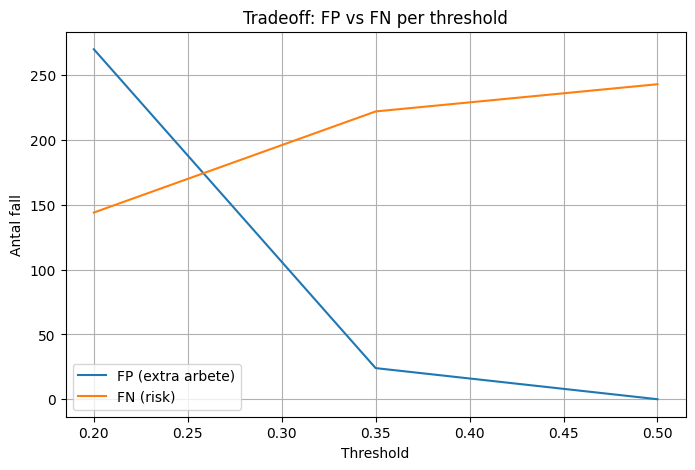

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df_results["Threshold"], df_results["FP"], label="FP (extra arbete)")
plt.plot(df_results["Threshold"], df_results["FN"], label="FN (risk)")
plt.xlabel("Threshold")
plt.ylabel("Antal fall")
plt.title("Tradeoff: FP vs FN per threshold")
plt.legend()
plt.grid(True)
plt.show()


# 3.8 Nästa steg: Optimering 

I grundjämförelsen presterade Logistic Regression bäst (F1 ≈ 0.087), medan Random Forest hade lägre grundprestanda (F1 ≈ 0.014). 
Vi väljer ändå att gå vidare med att optimera Random Forest. Skälet är att Random Forest har större förbättringspotential genom hyperparameter‑tuning och att modellen ger sannolikheter som fungerar bättre för våra threshold‑scenarier. 
Det gör det möjligt att styra balansen mellan risk (FN) och arbetsbelastning (FP) enligt kravkortet.

Förslag på plan för Uppgift 4:

- Testa ett mindre antal hyperparametrar (t.ex. n_estimators, max_depth, ev. class_weight='balanced').
- Utvärdera effekten på F1, FN och FP.
- Fortsätt analysera konsekvenser av olika thresholds så beslutsunderlaget är användbart för COO och Finance.

Målet är att hitta en konfiguration som ökar upptäcktsförmågan och minskar andelen missade misstänkta fall utan att skapa orimligt många falsklarm.

# 4) Optimering (Ummulbanin)

- Välj en “final” modell baserat på jämförelsen.
- Gör tuning på den valda modellen (litet grid, minst 1–2 parametrar).
- Förklara kort vad ni optimerade och varför (koppla till kravkortet).

# 5) Threshold/prioritering (Abdullahi)

Ni måste bestämma hur modellen ska användas i praktiken. Välj en strategi:

    A) Threshold-beslut
    - flagga misstänkt om proba ≥ t
    - motivera t utifrån kravkortet och visa konsekvenser (FP/FN eller precision/recall)
    
    B) Top-X prioritering
    - flagga de X% högst risk (t.ex. top 5% eller top 50 per dag)
    - motivera X utifrån kravkortet och visa konsekvenser
    - Ni ska tydligt visa hur ert val påverkar FP/FN och varför det passar er stakeholder.

# 6) Deploy-test: ny data (tisdag kursvecka 6)

- När ni får new_data.csv ska ni:
- använda er låsta pipeline
- skapa prediktioner och en prioriteringslista